# TP --- Pilotage d'un LLM pour l'analyse sismique d'une structure à 1 DDL
## Notebook solution --- correction enseignant

**UE Mathématiques et Modélisation --- 3ᵉ année**

Ce notebook constitue le corrigé du sujet de TP. Il est organisé en quatre parties
correspondant à l'énoncé. La partie 4 (analyse critique) fait l'objet d'un document
de référence séparé qui détaille les attendus.

**Architecture mise en œuvre :**

```
        ┌──────────────┐         ┌─────────────────┐         ┌─────────────────┐
texte → │ LLM extrait  │ params→ │ Python calcule   │ result→ │ Python formate  │ → réponse
        │ (LangChain)  │         │ (déterministe)   │         │ (déterministe)  │
        └──────────────┘         └─────────────────┘         └─────────────────┘
```

La LLM est appelée **une seule fois**, uniquement pour extraire des paramètres
structurés depuis une requête en langage naturel. Tout le reste --- calcul, contrôles
de cohérence, formatage de la sortie --- est du Python pur.

> ⚠️ La partie LangChain (sections 2, 3 et 4) nécessite une clé API.
> Le code utilise `langchain-anthropic` ; il est trivialement adaptable à `langchain-openai`.
> Si la clé est absente, les cellules concernées lèveront une erreur explicite et
> le notebook reste exploitable pour les parties analytiques.

## 0. Environnement

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

---
## 1. Solveur de référence

On résout :
$$m\,\ddot{x}(t) + c\,\dot{x}(t) + k\,x(t) = -m\,A\,\sin(\omega t)$$

avec $\omega_n = \sqrt{k/m}$, $\zeta = c/(2\sqrt{mk})$, $r = \omega/\omega_n$.

L'amplitude analytique en régime permanent :
$$X = \frac{A/\omega_n^2}{\sqrt{(1-r^2)^2 + (2\zeta r)^2}}$$

In [2]:
def solve_sdof(m, k, c, A, omega, t_max, n_points=None):
    """Intègre l'équation du mouvement d'un oscillateur 1 DDL sous excitation sinusoïdale."""
    if n_points is None:
        T_exc = 2 * np.pi / omega
        n_points = max(2000, int(40 * t_max / T_exc))
    t_eval = np.linspace(0, t_max, n_points)

    def rhs(t, y):
        x, xdot = y
        xddot = (-c * xdot - k * x - m * A * np.sin(omega * t)) / m
        return [xdot, xddot]

    sol = solve_ivp(rhs, [0, t_max], [0.0, 0.0], t_eval=t_eval,
                    method='RK45', rtol=1e-9, atol=1e-11)
    return sol.t, sol.y[0], sol.y[1]


def steady_state_amplitude(m, k, c, A, omega):
    """Amplitude analytique du déplacement en régime permanent."""
    omega_n = np.sqrt(k / m)
    zeta = c / (2 * np.sqrt(m * k))
    r = omega / omega_n
    return (A / omega_n**2) / np.sqrt((1 - r**2)**2 + (2 * zeta * r)**2)


def frequency_response(m, k, c, r_min=0.05, r_max=3.0, n=600, ax=None):
    """Trace le facteur d'amplification |H(r)| sur [r_min, r_max]."""
    omega_n = np.sqrt(k / m)
    zeta = c / (2 * np.sqrt(m * k))
    r = np.linspace(r_min, r_max, n)
    H = 1.0 / np.sqrt((1 - r**2)**2 + (2 * zeta * r)**2)

    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(r, H, lw=2)
    ax.axvline(1, color='crimson', ls='--', alpha=0.6, label='résonance ($r=1$)')
    ax.set_xlabel(r'$r = \omega / \omega_n$')
    ax.set_ylabel(r'$|H(r)|$')
    ax.set_title(f'Réponse en fréquence ($\zeta$ = {zeta:.3f})')
    ax.legend()
    return ax

<>:39: SyntaxWarning: invalid escape sequence '\z'
<>:39: SyntaxWarning: invalid escape sequence '\z'
/var/folders/g9/mjl_ltsx4t91cpvy26b308rc0000gn/T/ipykernel_47113/2999269560.py:39: SyntaxWarning: invalid escape sequence '\z'
  ax.set_title(f'Réponse en fréquence ($\zeta$ = {zeta:.3f})')


### Validation : convergence numérique vs analytique

omega_n = 20.000 rad/s  -->  f_n = 3.183 Hz



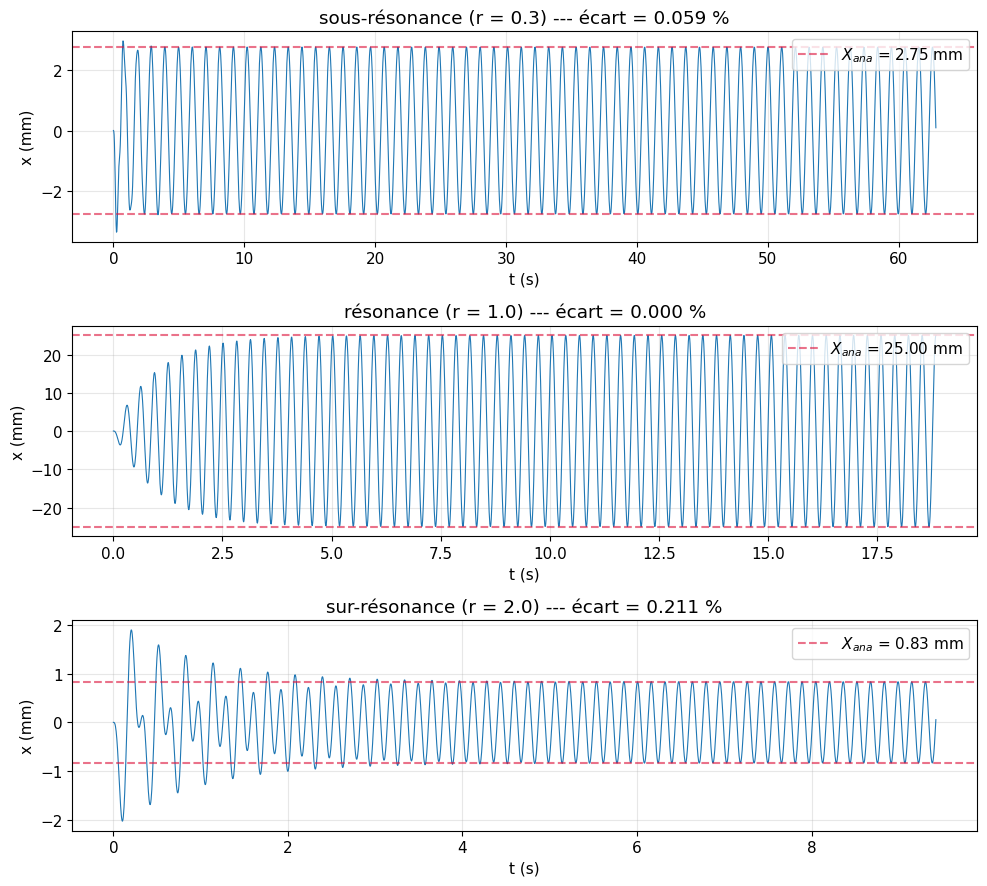

In [3]:
m, k, zeta = 50_000, 2.0e7, 0.05
c = 2 * zeta * np.sqrt(m * k)
omega_n = np.sqrt(k / m)
A = 1.0

print(f"omega_n = {omega_n:.3f} rad/s  -->  f_n = {omega_n/(2*np.pi):.3f} Hz\n")

cas_valid = [("sous-résonance", 0.3), ("résonance", 1.0), ("sur-résonance", 2.0)]

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
for ax, (label, r) in zip(axes, cas_valid):
    omega = r * omega_n
    t_max = 60 * (2 * np.pi / omega)
    t, x, _ = solve_sdof(m, k, c, A, omega, t_max)
    mask = t > 2 * t_max / 3
    X_num = (x[mask].max() - x[mask].min()) / 2
    X_ana = steady_state_amplitude(m, k, c, A, omega)
    err = abs(X_num - X_ana) / X_ana * 100

    ax.plot(t, x * 1000, lw=0.8)
    ax.axhline(X_ana * 1000, color='crimson', ls='--', alpha=0.6,
               label=f'$X_{{ana}}$ = {X_ana*1000:.2f} mm')
    ax.axhline(-X_ana * 1000, color='crimson', ls='--', alpha=0.6)
    ax.set_xlabel('t (s)'); ax.set_ylabel('x (mm)')
    ax.set_title(f'{label} (r = {r}) --- écart = {err:.3f} %')
    ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

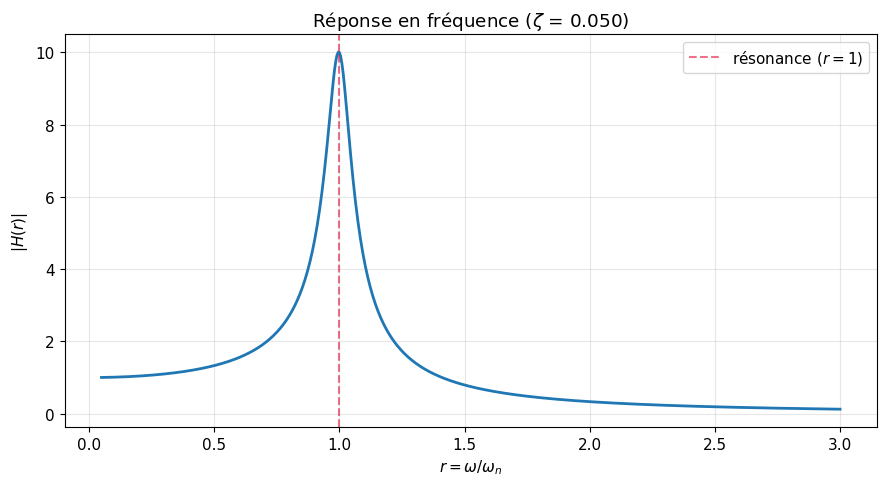

In [4]:
fig, ax = plt.subplots()
frequency_response(m, k, c, ax=ax)
plt.tight_layout(); plt.show()

---
## 2. Chaîne d'extraction LLM

On construit une **chaîne unique** qui transforme une requête textuelle en un objet Python
typé contenant les cinq paramètres physiques. La LLM n'a qu'un rôle : traduire le langage
naturel en données structurées. Aucune décision algorithmique, aucun calcul.

> Cette section utilise LangChain ≥ 0.3 et `langchain-anthropic`.
> Pour OpenAI : remplacer par `ChatOpenAI` et `OPENAI_API_KEY`.

In [5]:
HAS_API_KEY = bool(os.environ.get("ANTHROPIC_API_KEY"))
if not HAS_API_KEY:
    print("ANTHROPIC_API_KEY non définie : les sections LLM seront sautées.")
else:
    print("Clé API détectée. La chaîne peut être instanciée.")

ANTHROPIC_API_KEY non définie : les sections LLM seront sautées.


### 2.1 Schéma de sortie (Pydantic)

In [6]:
from typing import Optional
from pydantic import BaseModel, Field, field_validator


class SeismicParameters(BaseModel):
    """Paramètres physiques d'un oscillateur 1 DDL sous séisme sinusoïdal.

    Tous les champs sont en unités SI. Les bornes physiques sont vérifiées
    après extraction (pas par la LLM).
    """
    m: Optional[float]     = Field(default=None, description="Masse de la structure en kg")
    k: Optional[float]     = Field(default=None, description="Raideur en N/m")
    zeta: Optional[float]  = Field(default=None, description="Taux d'amortissement adimensionnel (0 à 1)")
    A: Optional[float]     = Field(default=None, description="Amplitude de l'accélération sismique en m/s²")
    omega: Optional[float] = Field(default=None, description="Pulsation de l'excitation en rad/s")

    def is_complete(self) -> bool:
        """Vérifie que tous les paramètres sont présents."""
        return all(v is not None for v in (self.m, self.k, self.zeta, self.A, self.omega))

    def validate_physics(self) -> list[str]:
        """Renvoie la liste des incohérences physiques détectées."""
        errs = []
        if self.m is not None and self.m <= 0: errs.append("masse non strictement positive")
        if self.k is not None and self.k <= 0: errs.append("raideur non strictement positive")
        if self.zeta is not None and not (0 < self.zeta < 1): errs.append(f"zeta hors [0, 1] (vaut {self.zeta})")
        if self.A is not None and self.A < 0: errs.append("amplitude négative")
        if self.omega is not None and self.omega <= 0: errs.append("omega non strictement positive")
        return errs

### 2.2 Construction de la chaîne

In [7]:
SYSTEM_PROMPT = """Tu extrais les paramètres physiques d'un problème de dynamique des structures
à partir d'une requête utilisateur. Tu renvoies UNIQUEMENT les valeurs structurées,
sans commentaire.

Conventions strictes :
- Toutes les valeurs sont en unités SI.
- Convertir tonnes -> kg (multiplier par 1000).
- Convertir Hz -> rad/s (multiplier par 2*pi).
- Convertir un pourcentage en fraction décimale (5% -> 0.05).
- Si une période propre T est fournie (en s), en déduire omega_n = 2*pi/T puis
  k = m * omega_n^2 si la masse est connue (sinon laisser k à None).

Règle absolue :
- N'invente AUCUNE valeur. Si une information n'est pas dans la requête, laisse le
  champ correspondant à None. Ne mets jamais une valeur par défaut implicite."""

if HAS_API_KEY:
    from langchain_anthropic import ChatAnthropic
    from langchain_core.prompts import ChatPromptTemplate

    llm = ChatAnthropic(model="claude-sonnet-4-6", temperature=0, max_tokens=512)
    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human", "{query}"),
    ])
    chain = prompt | llm.with_structured_output(SeismicParameters)
    print("Chaîne prête.")
else:
    chain = None

### 2.3 Test sur trois requêtes en langage naturel

In [8]:
def extract(query: str) -> SeismicParameters:
    """Wrapper qui interroge la chaîne si disponible, sinon lève une erreur."""
    if chain is None:
        raise RuntimeError("Chaîne non disponible : clé API absente.")
    t0 = time.time()
    params = chain.invoke({"query": query})
    print(f"[{time.time()-t0:.2f} s]")
    return params


Q1 = ("J'ai un bâtiment de 50 tonnes avec une raideur de 2e7 N/m et un amortissement "
      "de 5 %. Le séisme excite à 3 Hz avec une accélération de 1 m/s².")

if chain:
    p1 = extract(Q1)
    print(f"\n{p1.model_dump()}")
    print(f"Complet : {p1.is_complete()} | Erreurs physiques : {p1.validate_physics()}")

In [9]:
Q2 = ("Un bâtiment de 100 tonnes, raideur 2e7 N/m, amortissement faible (2%), "
      "subit un séisme à 4.5 Hz d'amplitude 1.5 m/s².")

if chain:
    p2 = extract(Q2)
    print(f"\n{p2.model_dump()}")
    print(f"Complet : {p2.is_complete()}")

In [10]:
Q3 = ("Une structure de 75 tonnes avec une période propre d'environ 0.4 s et 3% "
      "d'amortissement. Le sol oscille à 2.5 Hz avec 0.8 m/s².")

if chain:
    p3 = extract(Q3)
    print(f"\n{p3.model_dump()}")
    print("Note : k est déduit indirectement de m et T_n via k = m*(2π/T)².")

---
## 3. Étude de cas

Trois configurations imposées (Tableau 1 de l'énoncé) couvrant trois régimes
dynamiques distincts. Chaque cas est traité **deux fois** : via la chaîne (extraction LLM
puis calcul Python) et par appel direct au solveur de référence.

### 3.1 Fonction de formatage (Python pur)

In [11]:
def compute_and_format(params: SeismicParameters) -> str:
    """À partir des paramètres extraits, calcule la réponse et la formate.

    Tout est en Python pur : aucun appel LLM ici.
    """
    # Validation
    errs = params.validate_physics()
    if not params.is_complete():
        missing = [n for n in ['m','k','zeta','A','omega'] if getattr(params, n) is None]
        return f"⚠ Paramètres manquants : {', '.join(missing)}"
    if errs:
        return f"⚠ Incohérences physiques : {' ; '.join(errs)}"

    # Calcul
    m, k, zeta, A, omega = params.m, params.k, params.zeta, params.A, params.omega
    c = 2 * zeta * np.sqrt(m * k)
    omega_n = np.sqrt(k / m)
    r = omega / omega_n
    X = steady_state_amplitude(m, k, c, A, omega)

    # Diagnostic de régime (logique Python, pas LLM)
    if abs(r - 1) < 0.1:
        regime = "QUASI-RÉSONANCE (danger)"
    elif r < 0.9:
        regime = "sous-résonance"
    else:
        regime = "sur-résonance"

    return (
        f"Bâtiment : m = {m/1000:.1f} t, ωₙ = {omega_n:.2f} rad/s "
        f"(fₙ = {omega_n/(2*np.pi):.2f} Hz)\n"
        f"Excitation : ω = {omega:.2f} rad/s, r = {r:.3f}\n"
        f"Régime : {regime}\n"
        f"Déplacement maximal estimé : {X*1000:.2f} mm"
    )

### 3.2 Les trois configurations

In [12]:
cas = [
    {"nom": "A", "m": 50_000,  "k": 2.0e7, "zeta": 0.05, "A": 1.0, "omega": 10.0,
     "requete": "Bâtiment de 50 tonnes, raideur 2e7 N/m, amortissement 5%, "
                 "sous excitation sismique à 10 rad/s d'amplitude 1 m/s². Analyse ?"},
    {"nom": "B", "m": 50_000,  "k": 2.0e7, "zeta": 0.05, "A": 1.0, "omega": 20.0,
     "requete": "Même bâtiment (50 t, k = 2e7 N/m, zeta = 5%) avec excitation "
                 "à 20 rad/s, amplitude 1 m/s². Analyse ?"},
    {"nom": "C", "m": 100_000, "k": 2.0e7, "zeta": 0.02, "A": 1.5, "omega": 28.0,
     "requete": "Bâtiment de 100 tonnes, raideur 2e7 N/m, amortissement 2%, "
                 "excitation à 28 rad/s d'amplitude 1.5 m/s². Analyse ?"},
]

# Référence : calcul direct sans LLM
print("=== Référence (calcul direct, sans LLM) ===\n")
for c in cas:
    cv = 2 * c["zeta"] * np.sqrt(c["m"] * c["k"])
    X_ref = steady_state_amplitude(c["m"], c["k"], cv, c["A"], c["omega"])
    omega_n = np.sqrt(c["k"] / c["m"])
    r = c["omega"] / omega_n
    c["X_ref"] = X_ref
    print(f"Cas {c['nom']} : ωₙ = {omega_n:.2f} rad/s, r = {r:.3f}, X = {X_ref*1000:.3f} mm")

=== Référence (calcul direct, sans LLM) ===

Cas A : ωₙ = 20.00 rad/s, r = 0.500, X = 3.326 mm
Cas B : ωₙ = 20.00 rad/s, r = 1.000, X = 25.000 mm
Cas C : ωₙ = 14.14 rad/s, r = 1.980, X = 2.568 mm


**Lecture attendue des résultats :**

- **Cas A** (r = 0.5) : régime sous-critique, déplacement modéré (~3 mm). Structure sûre.
- **Cas B** (r = 1.0) : résonance exacte. Amplification 1/(2ζ) = 10. Déplacement de 25 mm.
- **Cas C** (r ≈ 1.98) : sur-résonance prononcée, déplacement faible (~2.6 mm) malgré
  une excitation plus forte (A = 1.5 m/s²) et un amortissement plus faible (ζ = 2%).
  Bonne occasion de discuter avec les élèves : un séisme « fort » mais à haute fréquence
  peut être moins préoccupant qu'un séisme « modéré » à la fréquence propre du bâtiment.

### 3.3 Mêmes cas via la chaîne LLM

In [13]:
for c in cas:
    print(f"\n{'='*70}\nCas {c['nom']} | X_ref = {c['X_ref']*1000:.3f} mm\n{'='*70}")
    print(f"Requête : {c['requete']}\n")
    if chain:
        params = extract(c['requete'])
        print(f"Paramètres extraits : {params.model_dump()}\n")
        print(compute_and_format(params))
    else:
        print("[Chaîne non disponible --- clé API absente]")


Cas A | X_ref = 3.326 mm
Requête : Bâtiment de 50 tonnes, raideur 2e7 N/m, amortissement 5%, sous excitation sismique à 10 rad/s d'amplitude 1 m/s². Analyse ?

[Chaîne non disponible --- clé API absente]

Cas B | X_ref = 25.000 mm
Requête : Même bâtiment (50 t, k = 2e7 N/m, zeta = 5%) avec excitation à 20 rad/s, amplitude 1 m/s². Analyse ?

[Chaîne non disponible --- clé API absente]

Cas C | X_ref = 2.568 mm
Requête : Bâtiment de 100 tonnes, raideur 2e7 N/m, amortissement 2%, excitation à 28 rad/s d'amplitude 1.5 m/s². Analyse ?

[Chaîne non disponible --- clé API absente]


---
## 4. Analyse critique

> Cette partie est le **cœur de l'évaluation** (30 % de la note). Le notebook se contente
> de fournir les expériences ; la rédaction de l'analyse appartient au rapport.
> Le document `analyse_critique_reference.pdf` détaille les attendus pour la correction.

### 4.1 Fidélité de l'extraction (reproductibilité)

In [14]:
req_repro = ("Bâtiment 50 tonnes, raideur 2e7 N/m, amortissement 5%, séisme 3 Hz "
             "d'amplitude 1 m/s². Paramètres ?")

if chain:
    extractions = []
    for i in range(3):
        p = chain.invoke({"query": req_repro})
        extractions.append(p)
        print(f"Run {i+1}: {p.model_dump()}")

    # Comparaison stricte des valeurs numériques
    ref = extractions[0].model_dump()
    all_identical = all(e.model_dump() == ref for e in extractions[1:])
    print(f"\nLes 3 extractions sont {'STRICTEMENT identiques' if all_identical else 'DIVERGENTES'}.")
else:
    print("[Chaîne non disponible]")

[Chaîne non disponible]


**À discuter dans le rapport :**
- À température 0, les sorties Pydantic devraient être identiques au bit près.
  Si elles divergent, c'est dû au sampling résiduel non-déterministe des LLM
  (arithmétique flottante GPU non associative).
- Comparer avec un script Python pur : ce dernier est toujours bit-à-bit reproductible.
- Comparaison à faire en complément : exécuter plusieurs fois `compute_and_format(params)`
  avec les mêmes paramètres — résultats strictement identiques (déterminisme Python).

### 4.2 Robustesse aux ambiguïtés

In [15]:
# Test 1 : unités omises
print("=== TEST 1 : UNITES OMISES ===")
if chain:
    p = chain.invoke({"query": "Bâtiment de 50, raideur 2e7, amortissement 5%, séisme 3 Hz amplitude 1."})
    print(p.model_dump())

=== TEST 1 : UNITES OMISES ===


In [16]:
# Test 2 : donnée indirecte (période propre au lieu de raideur)
print("=== TEST 2 : PERIODE PROPRE FOURNIE ===")
if chain:
    p = chain.invoke({"query": "Bâtiment de 50 tonnes, période propre d'environ 0.5 s, "
                                  "amortissement 5%. Séisme à 2 Hz d'amplitude 1 m/s²."})
    print(p.model_dump())
    print("Le LLM devrait calculer k = m*(2π/T)² = 50000*(2π/0.5)² ≈ 7.9e6 N/m.")

=== TEST 2 : PERIODE PROPRE FOURNIE ===


In [17]:
# Test 3 : valeur aberrante (amortissement 150%)
print("=== TEST 3 : AMORTISSEMENT ABERRANT ===")
if chain:
    p = chain.invoke({"query": "Bâtiment 50 tonnes, raideur 2e7 N/m, amortissement 150%, "
                                  "séisme 3 Hz amplitude 1 m/s². Réponse ?"})
    print(f"Paramètres : {p.model_dump()}")
    print(f"Erreurs détectées par Python : {p.validate_physics()}")
    print(f"\nMise en forme : {compute_and_format(p)}")

=== TEST 3 : AMORTISSEMENT ABERRANT ===


In [18]:
# Test 4 : paramètre manquant (pas d'amortissement)
print("=== TEST 4 : AMORTISSEMENT MANQUANT ===")
if chain:
    p = chain.invoke({"query": "Bâtiment 50 tonnes, raideur 2e7 N/m, séisme 3 Hz amplitude 1 m/s²."})
    print(f"Paramètres : {p.model_dump()}")
    print(f"\nMise en forme : {compute_and_format(p)}")

=== TEST 4 : AMORTISSEMENT MANQUANT ===


**À discuter :**
- Test 1 : le LLM suppose-t-il silencieusement « 50 tonnes » et « 1 m/s² » ? L'instruction
  système l'interdit, mais le LLM résiste rarement à compléter une requête ambiguë.
- Test 2 : la capacité du LLM à dériver `k` depuis `T` est élégante mais introduit du calcul
  dans la couche extraction. Discuter : est-ce souhaitable ? À l'inverse, on pourrait
  laisser la chaîne à None et déléguer la conversion à du code Python explicite.
- Test 3 : le LLM ne devrait pas alerter (c'est de l'extraction littérale). C'est
  `validate_physics()` côté Python qui doit attraper l'incohérence. **Leçon clé : la validation
  est codée en Python, pas dans le LLM.**
- Test 4 : `compute_and_format` détecte le champ manquant et renvoie un message d'erreur
  clair, sans calcul aberrant. C'est exactement ce qu'on veut.

### 4.3 Hors-champ : que renvoie la chaîne ?

In [19]:
print("=== HORS CHAMP ===")
if chain:
    p = chain.invoke({"query": "Quel ferraillage prévoir aux poteaux de ce bâtiment ?"})
    print(f"Paramètres : {p.model_dump()}")
    print(f"Complet : {p.is_complete()}")
    print(f"\nMise en forme : {compute_and_format(p)}")

=== HORS CHAMP ===


**À discuter :**
- Avec `with_structured_output` et tous les champs `Optional`, le LLM renvoie un objet
  `SeismicParameters` avec tous les champs à `None`. C'est précisément le bon
  comportement : il n'invente rien.
- `compute_and_format` détecte alors « paramètres manquants » et refuse de calculer.
- **C'est un garde-fou robuste** : la combinaison [Pydantic Optional + validation Python]
  empêche structurellement le système de répondre à une question qu'il n'est pas
  outillé pour traiter. Comparer avec le risque d'hallucination d'un agent libre.

### 4.4 Coût et impact énergétique

In [20]:
import timeit

m_, k_, zeta_, A_, omega_ = 50_000, 2.0e7, 0.05, 1.0, 10.0
c_ = 2 * zeta_ * np.sqrt(m_ * k_)

dt_direct = timeit.timeit(
    lambda: steady_state_amplitude(m_, k_, c_, A_, omega_),
    number=10_000
) / 10_000

print(f"Calcul analytique direct (formule)       : {dt_direct*1e6:.2f} µs")
print(f"Extraction LLM (typique)                  : ~1 à 3 s")
print(f"Coût LLM par requête (Sonnet 4)           : ~0.003 USD")
print(f"Énergie LLM par requête (ordre de grandeur) : ~1 Wh")
print(f"Énergie calcul direct                     : ~0.1 µJ")
print()
print(f"Rapport : l'extraction LLM est ~10^6 plus lente et coûte ~0.3 centime par requête.")
print(f"Mais elle est NÉCESSAIRE pour interpréter du langage naturel ; un script")
print(f"paramétré n'a pas ce besoin et l'extraction n'a alors plus lieu d'être.")

Calcul analytique direct (formule)       : 4.20 µs
Extraction LLM (typique)                  : ~1 à 3 s
Coût LLM par requête (Sonnet 4)           : ~0.003 USD
Énergie LLM par requête (ordre de grandeur) : ~1 Wh
Énergie calcul direct                     : ~0.1 µJ

Rapport : l'extraction LLM est ~10^6 plus lente et coûte ~0.3 centime par requête.
Mais elle est NÉCESSAIRE pour interpréter du langage naturel ; un script
paramétré n'a pas ce besoin et l'extraction n'a alors plus lieu d'être.


### 4.5 Positionnement en ingénierie

**Conclusion attendue dans le rapport élève :**

L'architecture *LLM en interface, calcul en Python* est légitime lorsque :

- l'entrée est en langage naturel (cahier des charges, e-mail client, rapport antérieur) ;
- les paramètres sont nombreux ou exprimés dans des unités hétérogènes ;
- l'utilisateur n'est pas un expert du formalisme (architecte interrogeant un modèle structure simplifié).

Elle est inutile lorsque :

- l'utilisateur est ingénieur et préfère renseigner directement les valeurs ;
- la requête a une structure fixe (un formulaire ou un fichier de configuration suffit).

Elle est inadaptée pour :

- les calculs eux-mêmes (le LLM ne doit jamais en faire) ;
- les questions normatives ou réglementaires (Eurocodes), où l'autorité du document prime ;
- les contextes audités (notes de calcul officielles) où la traçabilité bit-à-bit est exigée.

**Principe directeur** : la LLM est une couche de \emph{traduction}, pas un \emph{moteur de décision}.
Toutes les règles de validation, de calcul et de mise en forme restent dans du code Python
testé, versionné et reproductible.